In [2]:
# ================================
# PLANT COMMUNICATION DATASET MODEL (PRO VERSION)
# ================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression



In [3]:
# Style
sns.set_style("whitegrid")
sns.set_context("talk")



In [4]:
# Load dataset
df = pd.read_csv("E:\Internship_project\Dataset\Plant-communication-classification\plant_communication_dataset.csv")



In [5]:
print("\n📊 Dataset Preview:")
print(df.head())




📊 Dataset Preview:
   Leaf Vibration (Hz)  Pollen Scent Complexity (1–10)  \
0                21.85                               6   
1                47.78                               1   
2                37.94                               9   
3                31.94                               1   
4                12.02                               5   

   Bioluminescence Intensity (Lux)  Root Signal Strength (mV)  \
0                           799.92                     331.80   
1                           178.54                     169.34   
2                           652.75                     389.00   
3                           238.18                      74.13   
4                            99.44                     485.21   

   Growth Rate (mm/day)  Ambient Temperature (°C)  Soil Moisture Level (0–1)  \
0                  2.02                     19.57                       0.07   
1                  4.88                     27.47                       0.94   


In [6]:
print("\n📊 Dataset Info:")
print(df.info())




📊 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Leaf Vibration (Hz)              500 non-null    float64
 1   Pollen Scent Complexity (1–10)   500 non-null    int64  
 2   Bioluminescence Intensity (Lux)  500 non-null    float64
 3   Root Signal Strength (mV)        500 non-null    float64
 4   Growth Rate (mm/day)             500 non-null    float64
 5   Ambient Temperature (°C)         500 non-null    float64
 6   Soil Moisture Level (0–1)        500 non-null    float64
 7   Sunlight Exposure (hours)        500 non-null    float64
 8   Symbiotic Fungus Present (0/1)   500 non-null    int64  
 9   Communication Type               500 non-null    object 
dtypes: float64(7), int64(2), object(1)
memory usage: 39.2+ KB
None


In [7]:
# Encode categorical columns
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])



In [8]:
# Target column
target_column = "Communication Type"

# -------------------------------
# 🔥 Visualization Section
# -------------------------------



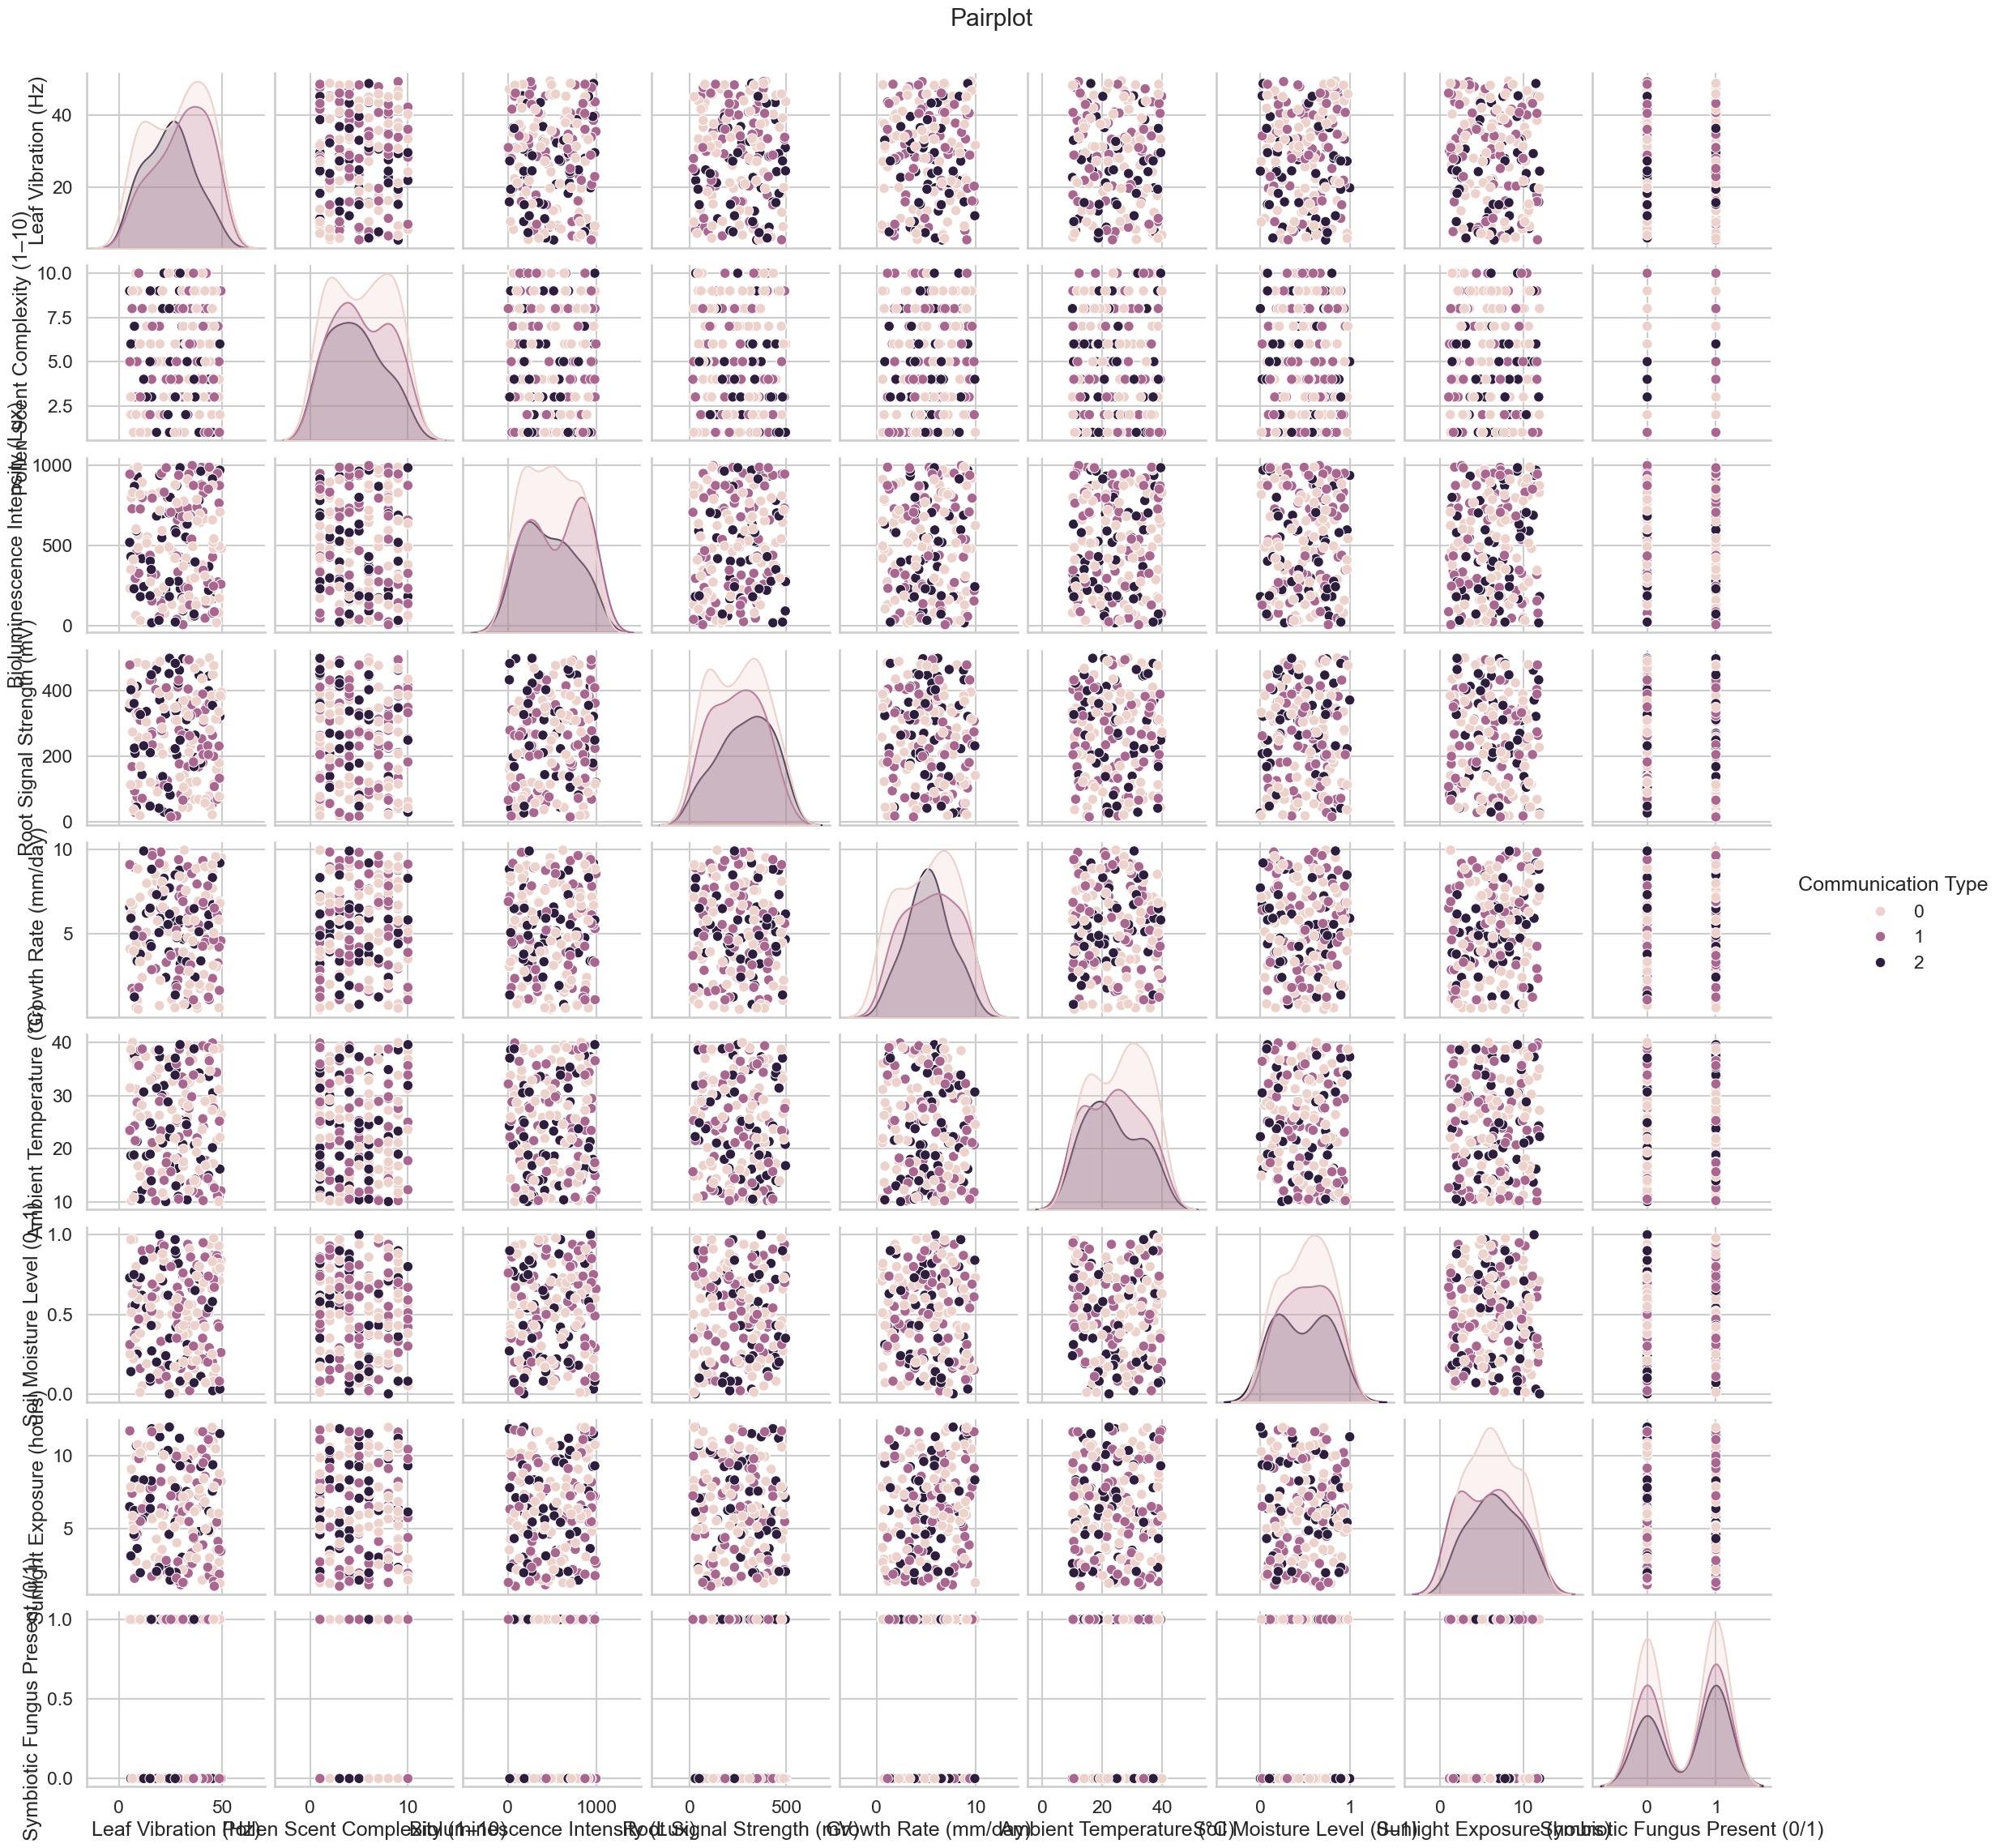

In [9]:
# Pairplot (sample for speed)
sns.pairplot(df.sample(min(200, len(df))), hue=target_column)
plt.suptitle("Pairplot", y=1.02)
plt.show()



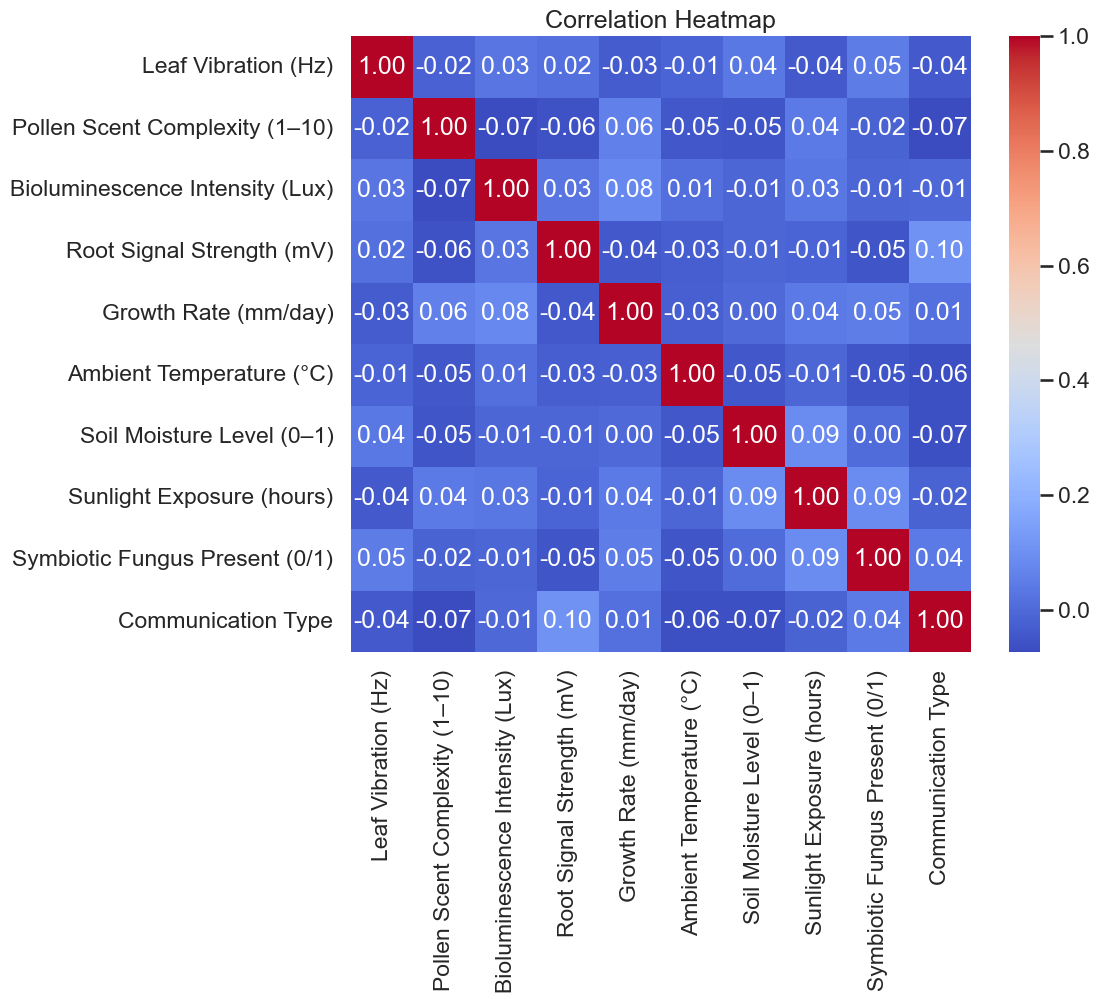

In [10]:
# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()



In [11]:
# -------------------------------
# Data Split
# -------------------------------

X = df.drop(target_column, axis=1)
y = df[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



In [12]:
# -------------------------------
# Models
# -------------------------------

models = {
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=1000)
}

accuracies = {}



In [13]:
# -------------------------------
# Training & Evaluation
# -------------------------------

print("\n🚀 Training Models...\n")

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    accuracies[name] = acc

    print(f"{name} Accuracy: {acc:.4f}")




🚀 Training Models...

KNN Accuracy: 0.3700
Random Forest Accuracy: 0.3200
Decision Tree Accuracy: 0.3000
Logistic Regression Accuracy: 0.3100



🏆 Best Model:
KNN with accuracy 0.3700


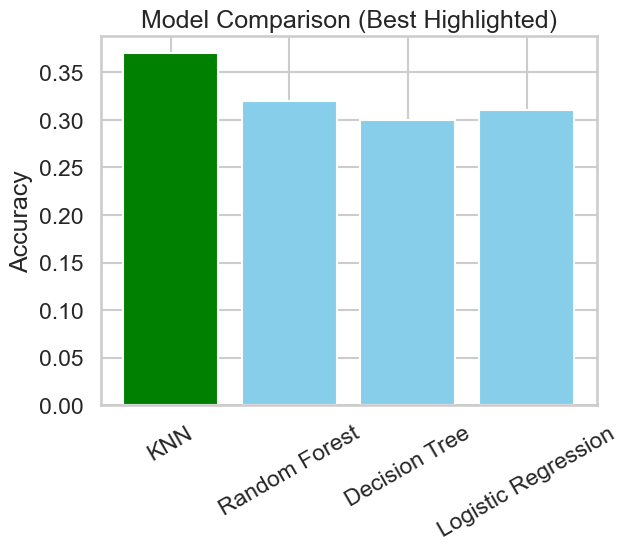

In [14]:
# -------------------------------
# Best Model
# -------------------------------

best_model_name = max(accuracies, key=accuracies.get)
best_model = models[best_model_name]

print("\n🏆 Best Model:")
print(f"{best_model_name} with accuracy {accuracies[best_model_name]:.4f}")

# -------------------------------
# Accuracy Comparison Plot
# -------------------------------

colors = ['green' if name == best_model_name else 'skyblue' for name in accuracies]

plt.figure()
plt.bar(accuracies.keys(), accuracies.values(), color=colors)
plt.title("Model Comparison (Best Highlighted)")
plt.xticks(rotation=30)
plt.ylabel("Accuracy")
plt.show()



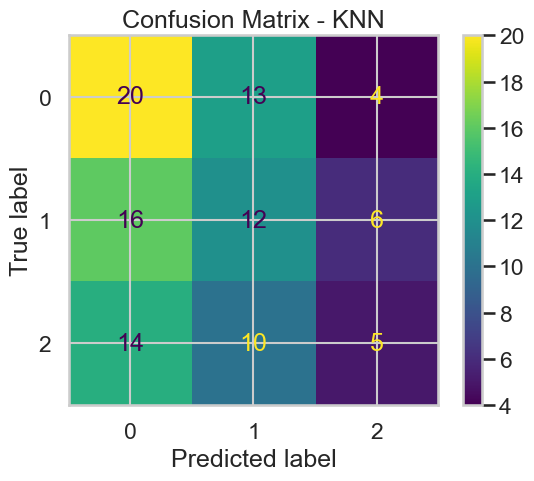

In [15]:
# -------------------------------
# Confusion Matrix (Best Model)
# -------------------------------

y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()



In [16]:
# -------------------------------
# Feature Importance (RF only)
# -------------------------------

if best_model_name == "Random Forest" or best_model_name == "Decision Tree":
    importances = best_model.feature_importances_

    feat_df = pd.DataFrame({
        "Feature": X.columns,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False).head(10)

    plt.figure(figsize=(10, 6))
    plt.barh(feat_df["Feature"], feat_df["Importance"])
    plt.gca().invert_yaxis()
    plt.title("Top Feature Importance")
    plt.xlabel("Importance")
    plt.show()



In [17]:
# -------------------------------
# Save Models
# -------------------------------

os.makedirs("plant_models", exist_ok=True)

for name, model in models.items():
    joblib.dump(model, f"plant_models/{name}.pkl")

joblib.dump(scaler, "plant_models/scaler.pkl")



['plant_models/scaler.pkl']

In [18]:
# -------------------------------
# Final Message
# -------------------------------

print("\n====================================")
print("✅ All models trained successfully")
print("✅ Models saved in 'plant_models' folder")
print(f"🏆 Best Model: {best_model_name}")
print("🚀 Project Completed Successfully!")
print("====================================")


✅ All models trained successfully
✅ Models saved in 'plant_models' folder
🏆 Best Model: KNN
🚀 Project Completed Successfully!
